# Flux normalization, compression and centering audit

The blue foundation-prior photometry measures amplitudes from the original pixels. Foundation features predict morphology; the foundation decoder is not part of that flux measurement.

**No global units/normalization or stale-state error was found in the tested CPU path. A real stellar-profile problem was found and a restricted repair added.** The seven-component mixture has no true point source without an explicit stellar flag. Its intrinsic-size floor biases noiseless VIS stars high by about 3.2–3.5%; a weak stellar core and the learned galaxy-profile prior increase this to about 28–32% in these diagnostics.

The new supplied-star option removes that bias to below 0.001%. It does not classify stars automatically. These are engineering checks, not the realistic faint-source comparison proposed for JAISP, Tractor and MER.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import display, Image
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'models/photometry').is_dir())
RUN = ROOT / 'models/photometry/self_supervised/runs/flux_path_audit'
audit = json.loads((RUN / 'audit.json').read_text())
measurements = pd.read_csv(RUN / 'stellar_checks.csv')
print(audit['protocol'])
print(audit['scope'])
print('Stellar cases:', measurements.case.nunique(), '; source/band/method rows:', len(measurements))


Noiseless point sources; realistic supplied variance; known positions; Gaussian exact-pixel truth or normalized archive finite stamps; no fitting/retraining to truth
Engineering audit, not a realistic galaxy/SED faint-end benchmark. Archive PSF truth shares the convolution routine with the pixelized fitter; Gaussian truth is independent.
Stellar cases: 14 ; source/band/method rows: 800


## Science units, compression and repeat calls

30 prepared science arrays (one scene per original sky partition, all ten bands) match their source NPZ cutouts exactly. Native source positions use the WCS and cutout origin, preserving fractional pixel coordinates. This sampled identity check does not validate external archive photometric zero points.

The loaded v11 stems use $y=50\,\mathrm{asinh}(x/50)$ with $x=I/\mathrm{RMS}$. The inverse is $x=50\,\mathrm{sinh}(y/50)$, so a reconstructed image would require $I=\mathrm{RMS}\,50\,\mathrm{sinh}(y/50)$. Simply multiplying the compressed decoder output by RMS would be wrong. **The photometry path does not consume that decoder output.** Its separate raw-feature compression, $\mathrm{asinh}[(I-\mathrm{sky})/(5\,\mathrm{RMS})]$, also affects only the prior inputs.

The older v10 S/N-100 hard clamp is documented in `io/23_astrometry_bright_worseners.ipynb`; the current checkpoint uses the v11 soft compression. Repeated A→changed-input→A calls below test CPU state/cache behavior. Unit changes multiply images by 7 and variances by 49; the measured flux must increase by 7.

In [2]:
display(pd.DataFrame(audit['science_pixels']))
print('Stem compression modes:', set(audit['compression_modes'].values()))
print('Maximum float32 compression round-trip relative error:', audit['asinh_roundtrip_max_relative_error'])
display(pd.DataFrame(audit['repeat_and_units']))
assert all(x['pixels_identical'] for x in audit['science_pixels'])
assert max(x['max_position_residual_px'] for x in audit['science_pixels']) < 2e-4
assert all(x['max_feature_difference'] == 0 and x['max_flux_difference'] == 0 for x in audit['repeat_and_units'])
assert max(x['max_unit_scaling_relative_error'] for x in audit['repeat_and_units']) < 1e-6


Stem compression modes: {'asinh50'}
Maximum float32 compression round-trip relative error: 3.906249901319825e-07


,split,band,pixels_identical,max_position_residual_px
0,train,rubin_u,True,0.000003
1,train,rubin_g,True,0.000003
2,train,rubin_r,True,0.000003
3,train,rubin_i,True,0.000003
4,train,rubin_z,True,0.000003
5,train,rubin_y,True,0.000003
6,train,euclid_VIS,True,0.000007
7,train,euclid_Y,True,0.000007
8,train,euclid_J,True,0.000007
9,train,euclid_H,True,0.000007


,psf,max_feature_difference,max_flux_difference,max_unit_scaling_relative_error
0,gaussian,0.0,0.0,3.947605e-08
1,archive,0.0,0.0,8.272362e-08


## Stars: separate the solver from the morphology model

Gaussian truth uses independent exact error-function pixel integrals. Archive truth uses one delivered finite stamp per Euclid band; it shares the Fourier convolution routine with the pixelized fitter, so it is an interface check rather than independent PSF validation. Every scene is noiseless, with the supplied survey variance retained to control prior strength. Peak pixel S/N is not total source S/N.

`matched_psf_only` supplies the true stellar shape to the linear solver. `unregularized_mixture` fits the original seven-component dictionary without the learned prior. `foundation` is the current blue-curve pipeline. `foundation_known_stars` uses the supplied stellar classification to fix intrinsic size to zero. The latter is a restricted test: **truth classes must not be passed to a future blind comparison unless every method receives the same information**.

The plots show medians across two subpixel phases, with markers at the three tested peak S/N values. There is no noise ensemble or confidence interval here.

Maximum absolute stellar-flag flux error (%): 0.000377562222753


median        min        max
psf      peak_snr mode                                                   
archive  5.0      foundation              31.450387  30.932504  31.968271
                  foundation_known_stars  -0.000002  -0.000002  -0.000001
                  image                   40.533775  37.040536  44.027014
                  matched_psf_only        -0.000002  -0.000002  -0.000001
                  unregularized_mixture    3.482136   3.480284   3.483988
         100.0    foundation               3.486914   3.484367   3.489460
                  foundation_known_stars  -0.000001  -0.000001  -0.000001
                  image                    3.486914   3.484367   3.489460
                  matched_psf_only        -0.000001  -0.000001  -0.000001
                  unregularized_mixture    3.486914   3.484367   3.489460
         5000.0   foundation               3.486913   3.484366   3.489460
                  foundation_known_stars  -0.000002  -0.000003  -0.000002
                  image                    3.486913   3.484366   3.489460
                  matched_psf_only        -0.000002  -0.000002  -0.000002
                  unregularized_mixture    3.486913   3.484366   3.489460
gaussian 5.0      foundation              28.387056  27.531407  29.242705
                  foundation_known_stars  -0.000241  -0.000286  -0.000196
                  image                   43.201423  39.620892  46.781953
                  matched_psf_only         0.000000   0.000000   0.000001
                  unregularized_mixture    3.175224   3.170066   3.180381
         100.0    foundation               3.175217   3.170056   3.180378
                  foundation_known_stars  -0.000241  -0.000286  -0.000196
                  image                    3.175217   3.170056   3.180378
                  matched_psf_only         0.000001   0.000001   0.000001
                  unregularized_mixture    3.175217   3.170056   3.180378
         5000.0   foundation               3.175214   3.170052   3.180377
                  foundation_known_stars  -0.000243  -0.000287  -0.000199
                  image                    3.175214   3.170052   3.180377
                  matched_psf_only        -0.000002  -0.000003  -0.000000
                  unregularized_mixture    3.175214   3.170052   3.180377

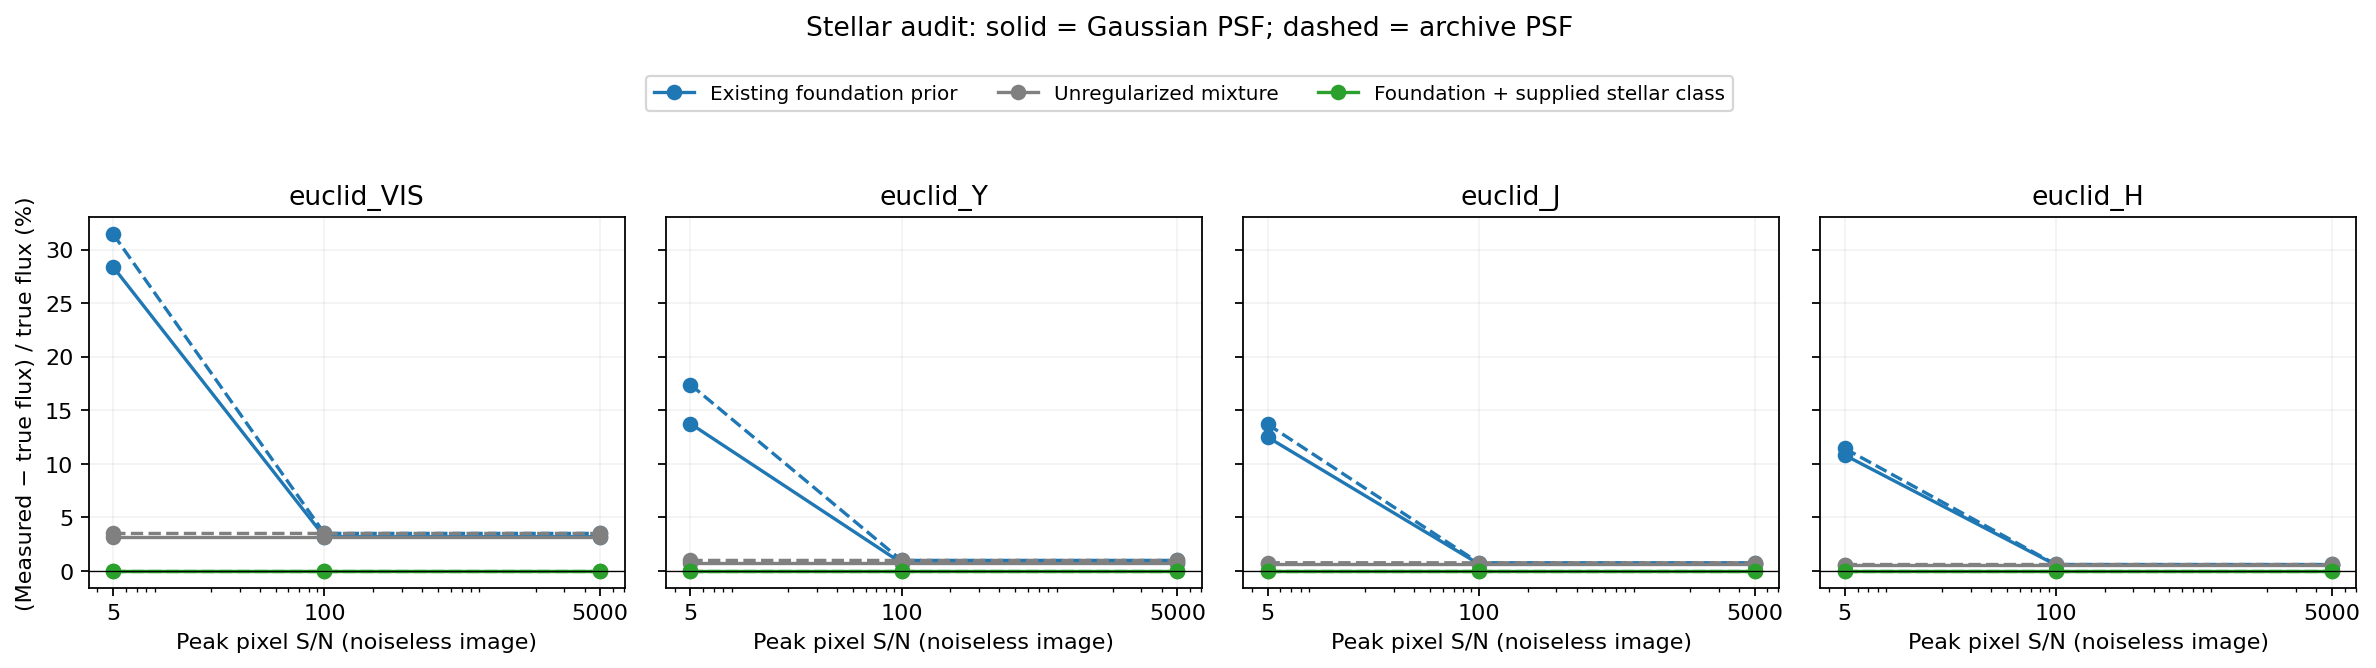

In [3]:
isolated = measurements[~measurements.blended]
vis = isolated[isolated.band.eq('euclid_VIS')]
display(vis.groupby(['psf','peak_snr','mode']).flux_error_percent.agg(['median','min','max']).round(6))
fig, axes = plt.subplots(1, 4, figsize=(15, 4), sharey=True)
labels = {'foundation':'Existing foundation prior', 'unregularized_mixture':'Unregularized mixture',
          'foundation_known_stars':'Foundation + supplied stellar class'}
colors = {'foundation':'C0', 'unregularized_mixture':'0.5', 'foundation_known_stars':'C2'}
for band, ax in zip(['euclid_VIS','euclid_Y','euclid_J','euclid_H'], axes):
    for mode in labels:
        for psf, style in [('gaussian','-'), ('archive','--')]:
            group = isolated[isolated.band.eq(band) & isolated['mode'].eq(mode) & isolated.psf.eq(psf)]
            median = group.groupby('peak_snr').flux_error_percent.median()
            ax.plot(median.index, median.values, marker='o', linestyle=style, color=colors[mode],
                    label=labels[mode] if psf == 'gaussian' else None)
    ax.axhline(0, color='k', linewidth=.6)
    ax.set_xscale('log'); ax.set_xticks([5, 100, 5000], ['5','100','5000'])
    ax.set_title(band); ax.set_xlabel('Peak pixel S/N (noiseless image)'); ax.grid(alpha=.15)
axes[0].set_ylabel('(Measured − true flux) / true flux (%)')
fig.legend(*axes[0].get_legend_handles_labels(), loc='upper center', ncol=3, fontsize=9, bbox_to_anchor=(.5, .96))
fig.suptitle('Stellar audit: solid = Gaussian PSF; dashed = archive PSF', y=1.04)
fig.tight_layout(rect=(0,0,1,.9))
fig.savefig(RUN / 'stellar_flux_audit.png', dpi=160, bbox_inches='tight')
fig.savefig(RUN / 'stellar_flux_audit.pdf', bbox_inches='tight')
plt.close(fig)
display(Image(filename=str(RUN / "stellar_flux_audit.png")))
fixed = measurements[measurements['mode'].eq('foundation_known_stars')]
print('Maximum absolute stellar-flag flux error (%):', fixed.flux_error_percent.abs().max())
assert fixed.flux_error_percent.abs().max() < .001


## Feature alignment is approximate even though flux centers are correct

The encoder fuses band arrays with size-based interpolation and does not consume WCS information. Scene crops are rounded independently in the native grids. At central sources, a VIS-to-Rubin resize can differ from the actual WCS position by about 0.081 arcsec median and 0.164 arcsec maximum across the original prepared scenes.

This table measures only central-source feature alignment. It does not capture all rotations, outer-source offsets, or pretraining alignment. The native flux templates still use each band's actual WCS positions; the sampled native-position check above passes. The alignment approximation could affect morphology predictions, but this audit does not assign a causal flux error to it. Changing encoder registration requires a consistent feature/training convention and reevaluation.

In [4]:
display(pd.DataFrame(audit['encoder_alignment']).T.rename(columns={'median':'Median offset (arcsec)', 'max':'Maximum offset (arcsec)'}).round(6))


,Median offset (arcsec),Maximum offset (arcsec)
euclid_H,0.000000,0.000000
euclid_J,0.000000,0.000000
euclid_VIS,0.000000,0.000000
euclid_Y,0.000000,0.000000
rubin_g,0.080819,0.163775
rubin_i,0.080819,0.163775
rubin_r,0.080819,0.163775
rubin_u,0.080819,0.163775
rubin_y,0.080819,0.163775
rubin_z,0.080819,0.163775


## Separate experimental scarlet renderer: unit mass is not sufficient

This renderer samples/interpolates the intrinsic morphology, integrates it over native pixels, then convolves with a PSF stamp that already includes pixel response. Independent continuous-Gaussian checks reveal additional profile smoothing and +0.3% to +5.3% flux errors across the tested sizes and grids, even though total template mass is approximately one.

A same-grid, integer-center diagnostic omits the intrinsic pixel integration before the pixel-integrated PSF; its flux errors are shown separately. This isolates the extra smoothing. **Using one sample is not a general repair on rotated or coarser grids.** A revised renderer needs an explicit intrinsic-grid/pixel-response convention, convergence checks, and compatible retraining/checkpoint versioning. This is separate from the mixture renderer used for the original blue curves.

In [5]:
display(pd.DataFrame(audit['scarlet_renderer']).round(6))


,intrinsic_sigma_arcsec,pixel_scale_arcsec,mass,flux_error_percent,extra_variance_px2,same_grid_point_sampled_flux_error_percent
0,0.1,0.1,1.000000,5.303417,0.222178,-0.000640
1,0.1,0.2,1.001151,1.022683,0.115597,NaN
2,0.3,0.1,1.000000,1.121334,0.222181,-0.000141
3,0.3,0.2,1.000000,0.850309,0.118736,NaN
4,0.6,0.1,1.000000,0.322275,0.221802,-0.000142
5,0.6,0.2,1.000000,0.441602,0.118649,NaN


## Restricted stellar repair and reproducibility

Mixture photometers accept a boolean mask in scene source order:

```python
scene['point_sources'] = np.asarray(independent_stellar_flags, dtype=bool)
measurements = photometer(scene)  # MixturePhotometry or BandPriorPhotometry
```

Flagged sources use PSF-only templates in all bands. The existing seven-weight checkpoints remain compatible, and unflagged galaxies retain their original profiles. No historical catalogs or benchmarks were overwritten; no stellar classifier or automatic production-catalog relabeling was introduced. The scarlet head is not covered by this option.

```bash
OPENBLAS_NUM_THREADS=2 OMP_NUM_THREADS=2 python -m models.photometry.self_supervised.audit_flux_path
python -m unittest discover -s models/photometry/self_supervised/tests -v
models/photometry/self_supervised/runs/tractor_env/bin/python -m unittest models.photometry.self_supervised.tests.test_tractor_bridge -v
```

The realistic simulation should use an independent renderer, clumps/irregular morphology, realistic joint SEDs, local empirical PSFs and controlled mismatch, real backgrounds and correlated noise, blends, and detection/position errors. Freeze all competing models before the final faint-end test. To score MER against injected truth, its measurement pipeline must process those same images; a static catalog cannot measure newly injected objects.